# SUNSET · Nowcast (adapted for Colab + Google Drive)

Original model from the SKIPP'D repo, wired to **your** setup: it reads the
`images_pv_processed.hdf5` you built in notebook 2 from `/content/drive/MyDrive/SKIPPD/`.

**Unchanged:** the SUNSET CNN architecture and the day-block cross-validation / ensembling method.
**Adapted:** data paths → your Drive; the HDF5-index `tf.data` pipeline → in-memory loading (robust on
Colab, and your one month of data fits in RAM); the test plots → auto-selected test days (the original
hardcodes specific 2019 dates that aren't in your data).

### Mount Drive & imports

In [2]:
import os
from google.colab import drive
if not os.path.ismount('/content/drive'):
    drive.mount('/content/drive')
else:
    print("Drive already mounted")

BASE = "/content/drive/MyDrive/SKIPPD"
print("Contents:", os.listdir(BASE))

Drive already mounted
Contents: ['2019_pv_raw.csv', 'pv_processed_10s.csv', 'images_raw', 'images_pv_processed.hdf5', 'times_test.npy', 'times_trainval.npy', 'model_output', 'forecast_samples.npz']


In [3]:
import tensorflow as tf
from tensorflow import keras
import numpy as np, matplotlib.pyplot as plt
import time, datetime, itertools, h5py
import matplotlib.dates as mdates
import pandas as pd
%matplotlib inline

print("tensorflow version:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print("available gpus:", gpus)
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

tensorflow version: 2.20.0
available gpus: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### Data & output locations (in Drive)

In [4]:
data_path = os.path.join(BASE, "images_pv_processed.hdf5")   # from notebook 2

model_name    = "SUNSET_nowcast_run"
output_folder = os.path.join(BASE, "model_output", model_name)
os.makedirs(output_folder, exist_ok=True)

print("data_path:", data_path, "| exists:", os.path.isfile(data_path))
print("output_folder:", output_folder)

data_path: /content/drive/MyDrive/SKIPPD/images_pv_processed.hdf5 | exists: True
output_folder: /content/drive/MyDrive/SKIPPD/model_output/SUNSET_nowcast_run


### Inspect the HDF5 structure

In [5]:
with h5py.File(data_path, "r") as f:
    f.visit(lambda n: print(n, f[n]) if isinstance(f[n], h5py.Dataset) else None)

test/images_log <HDF5 dataset "images_log": shape (427, 64, 64, 3), type "|u1">
test/pv_log <HDF5 dataset "pv_log": shape (427,), type "<f4">
trainval/images_log <HDF5 dataset "images_log": shape (2416, 64, 64, 3), type "|u1">
trainval/pv_log <HDF5 dataset "pv_log": shape (2416,), type "<f4">


### Load everything into memory

Your dataset is small enough to load fully (far simpler and faster on Colab than the original
per-index HDF5 reader). Images stay as `uint8`; a `Rescaling` layer normalizes them to `[0,1]` inside
the model.

In [6]:
with h5py.File(data_path, "r") as f:
    X_trainval = f["trainval/images_log"][...]     # (N, 64, 64, 3) uint8
    y_trainval = f["trainval/pv_log"][...].astype("float32")
    X_test     = f["test/images_log"][...]
    y_test     = f["test/pv_log"][...].astype("float32")

times_trainval = np.load(os.path.join(BASE, "times_trainval.npy"), allow_pickle=True)
times_test     = np.load(os.path.join(BASE, "times_test.npy"),     allow_pickle=True)

img_side_len, num_color_channel = X_trainval.shape[1], X_trainval.shape[3]
image_input_dim = [img_side_len, img_side_len, num_color_channel]
print("trainval:", X_trainval.shape, "| test:", X_test.shape)
print("image_input_dim:", image_input_dim)
print("PV range (kW): {:.2f} .. {:.2f}".format(y_trainval.min(), y_trainval.max()))

trainval: (2416, 64, 64, 3) | test: (427, 64, 64, 3)
image_input_dim: [64, 64, 3]
PV range (kW): 0.00 .. 22.84


### Input-pipeline helpers (unchanged from the repo)

In [7]:
# day block shuffling of the time stamps, and return shuffled indices
def day_block_shuffle(times_trainval):
    # robustly get a date for each timestamp (handles datetime, datetime64, str)
    ts = pd.to_datetime(np.asarray(times_trainval))
    dates = np.array([d.date() for d in ts])

    unique_dates = np.unique(dates)
    blocks = [np.where(dates == ud)[0] for ud in unique_dates]

    # shuffle the ORDER of the day-blocks (by index), not the ragged array itself
    np.random.seed(1)
    order = np.random.permutation(len(blocks))
    shuffled_indices = np.concatenate([blocks[k] for k in order])
    return shuffled_indices

# cross-validation split of the dayblock-shuffled indices
def cv_split(split_data, fold_index, num_fold):
    num_samples = len(split_data)
    indices = np.arange(num_samples)
    val_mask = np.zeros(num_samples, dtype=bool)
    val_mask[int(fold_index / num_fold * num_samples):int((fold_index + 1) / num_fold * num_samples)] = True
    val_indices = indices[val_mask]
    train_indices = indices[np.logical_not(val_mask)]
    np.random.seed(fold_index)
    np.random.shuffle(train_indices); np.random.shuffle(val_indices)
    return split_data[train_indices], split_data[val_indices]

### Model architecture (SUNSET — unchanged)

Only addition: a `Rescaling(1/255)` layer at the input so the in-memory `uint8` images are normalized
exactly like the original `convert_image_dtype` did.

In [8]:
# model characteristics (from the paper)
num_filters = 24
kernel_size = [3, 3]
pool_size   = [2, 2]
strides     = 2
dense_size  = 1024
drop_rate   = 0.4

# training parameters — tuned for a single month of data on Colab.
# (The paper used lr=3e-6, num_fold=10, num_epochs=200 over 3 years of data.)
num_epochs    = 100
num_fold      = 3          # set to 10 to match the paper (slower)
batch_size    = 64
learning_rate = 1e-4       # set to 3e-6 to match the paper (needs far more epochs/data)

In [9]:
def sunset_model():
    x_in = keras.Input(shape=image_input_dim)
    x = keras.layers.Rescaling(1./255)(x_in)                     # normalize uint8 -> [0,1]

    x = keras.layers.Conv2D(num_filters, kernel_size, padding="same", activation='relu')(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.MaxPooling2D(pool_size, strides)(x)

    x = keras.layers.Conv2D(num_filters*2, kernel_size, padding="same", activation='relu')(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.MaxPooling2D(pool_size, strides)(x)

    x = keras.layers.Flatten()(x)
    x = keras.layers.Dense(dense_size, activation='relu')(x)
    x = keras.layers.Dropout(drop_rate)(x)
    x = keras.layers.Dense(dense_size, activation='relu')(x)
    x = keras.layers.Dropout(drop_rate)(x)
    y_out = keras.layers.Dense(units=1)(x)
    return keras.Model(inputs=x_in, outputs=y_out)

sunset_model().summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 24)     │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 24)     │            96 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 48)     │        10,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 48)     │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │    12,583,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         1,025 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,645,937 (52.06 MB)

 Trainable params: 13,645,793 (52.05 MB)

 Non-trainable params: 144 (576.00 B)

### Train (day-block CV ensemble)

Same method as the repo — each fold reinitializes the model, trains with early stopping, and saves the
best checkpoint to Drive. Reads arrays straight from memory instead of the HDF5 index pipeline.

In [10]:
train_loss_hist = []
val_loss_hist = []

# Define indices_dayblock_shuffled before the loop
indices_dayblock_shuffled = day_block_shuffle(times_trainval)

for i in range(num_fold):
    print(f"\n{'='*20} Repetition {i+1}/{num_fold} {'='*20}")

    model = sunset_model()
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='mse',
                  metrics=['mae'])

    # split data
    X_train, X_val = cv_split(X_trainval[indices_dayblock_shuffled], i, num_fold)
    y_train, y_val = cv_split(y_trainval[indices_dayblock_shuffled], i, num_fold)

    # callbacks
    checkpoint_filepath = os.path.join(output_folder, f"repetition_{i+1}", f"best_model_repitition_{i+1}.keras")
    os.makedirs(os.path.dirname(checkpoint_filepath), exist_ok=True)
    model_checkpoint_callback = keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_filepath,
        save_weights_only=False,
        monitor='val_loss',
        mode='min',
        save_best_only=True)

    early_stopping_callback = keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    )

    history = model.fit(X_train, y_train,
                        batch_size=batch_size,
                        epochs=num_epochs,
                        validation_data=(X_val, y_val),
                        callbacks=[model_checkpoint_callback, early_stopping_callback],
                        verbose=1)

    train_loss_hist.append(history.history['loss'])
    val_loss_hist.append(history.history['val_loss'])

print('\nTraining complete for all folds!')


==================== Repetition 1/3 ====================
Epoch 1/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 22s 577ms/step - loss: 33.1889 - mae: 4.2177 - val_loss: 112.0057 - val_mae: 9.2655
Epoch 2/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 7.1624 - mae: 2.0910 - val_loss: 102.1820 - val_mae: 8.7724
Epoch 3/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 165ms/step - loss: 4.8288 - mae: 1.6870 - val_loss: 92.5899 - val_mae: 8.2823
Epoch 4/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 4.4929 - mae: 1.6180 - val_loss: 82.8624 - val_mae: 7.7735
Epoch 5/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 3.4003 - mae: 1.4268 - val_loss: 76.2330 - val_mae: 7.4223
Epoch 6/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 3.2872 - mae: 1.3873 - val_loss: 70.4055 - val_mae: 7.1129
Epoch 7/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 194ms/step - loss: 3.0542 - mae: 1.3272 - val_loss: 62.0079 - val_mae: 6.6362
Epoch 8/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 2.5038 - mae: 1.2305 - val_loss: 57.9923 -

In [11]:
print(type(times_trainval), times_trainval.shape, times_trainval.dtype)
print("sample:", times_trainval[0], type(times_trainval[0]))

<class 'numpy.ndarray'> (2416,) datetime64[us]
sample: 2019-01-24T07:31:30.000000 <class 'numpy.datetime64'>


### CV summary (unchanged)

In [12]:
n_done = len(val_loss_hist)
if n_done == 0:
    raise RuntimeError("No training history — run the training cell above first.")

best_train_loss_MSE = np.zeros(n_done)
best_val_loss_MSE   = np.zeros(n_done)
for i in range(n_done):
    best_val_loss_MSE[i] = np.min(val_loss_hist[i])
    idx = np.argmin(val_loss_hist[i])
    best_train_loss_MSE[i] = train_loss_hist[i][idx]
    print('Model {0} -- train RMSE: {1:.2f}, val RMSE: {2:.2f}'.format(
          i+1, np.sqrt(best_train_loss_MSE[i]), np.sqrt(best_val_loss_MSE[i])))
print('Mean train RMSE: {0:.2f}'.format(np.mean(np.sqrt(best_train_loss_MSE))))
print('Mean val   RMSE: {0:.2f}'.format(np.mean(np.sqrt(best_val_loss_MSE))))

Model 1 -- train RMSE: 1.29, val RMSE: 3.90
Model 2 -- train RMSE: 1.20, val RMSE: 4.30
Model 3 -- train RMSE: 1.25, val RMSE: 3.15
Mean train RMSE: 1.25
Mean val   RMSE: 3.78


### Test — load the ensemble, predict, score

In [13]:
prediction = np.zeros((num_fold, len(y_test)))
for i in range(num_fold):
    model_path = os.path.join(output_folder, f"repetition_{i+1}", f"best_model_repitition_{i+1}.keras")
    print("loading", model_path)
    model = keras.models.load_model(model_path)
    prediction[i] = np.squeeze(model.predict(X_test, batch_size=200, verbose=0))

np.save(os.path.join(output_folder, 'test_predictions.npy'), prediction)

prediction_ensemble = np.mean(prediction, axis=0)
rmse = np.sqrt(np.mean((prediction_ensemble - y_test)**2))
mae  = np.mean(np.abs(prediction_ensemble - y_test))
print("-"*50)
print(f"Test RMSE (ensemble): {rmse:.3f} kW")
print(f"Test MAE  (ensemble): {mae:.3f} kW")

loading /content/drive/MyDrive/SKIPPD/model_output/SUNSET_nowcast_run/repetition_1/best_model_repitition_1.keras
loading /content/drive/MyDrive/SKIPPD/model_output/SUNSET_nowcast_run/repetition_2/best_model_repitition_2.keras
loading /content/drive/MyDrive/SKIPPD/model_output/SUNSET_nowcast_run/repetition_3/best_model_repitition_3.keras


--------------------------------------------------
Test RMSE (ensemble): 3.276 kW
Test MAE  (ensemble): 2.342 kW


### Visualize predictions (auto-selected test days)

The original notebook hardcodes 20 specific 2017–2019 dates; those aren't in your January-2019 data,
so this instead plots whichever test days you actually have.

Test days available: 1


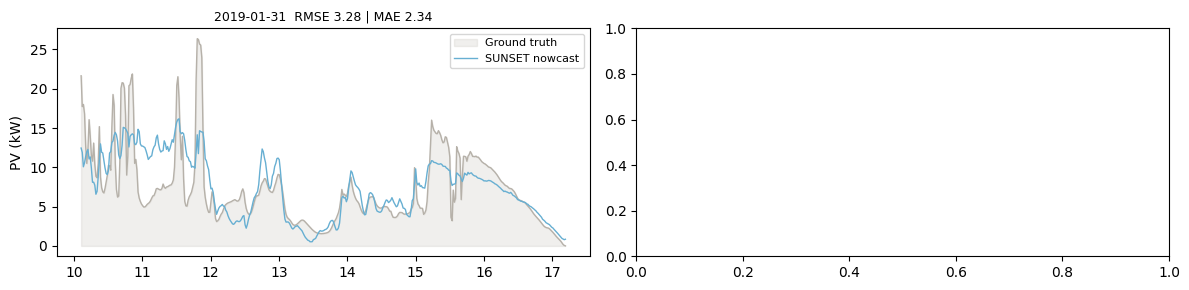

In [14]:
dates_test = pd.to_datetime(times_test).date
hours_test = pd.to_datetime(times_test).time
unique_days = sorted(np.unique(dates_test))
print("Test days available:", len(unique_days))

show = unique_days[:min(6, len(unique_days))]
fmt_date = datetime.date(2000, 1, 1)
xfmt = mdates.DateFormatter('%H')
grey, blue = '#B6B1A9', '#67AFD2'

n = len(show)
fig, axes = plt.subplots((n+1)//2, 2, figsize=(12, 3*((n+1)//2)), squeeze=False)
for k, day in enumerate(show):
    ax = axes[k//2][k%2]
    m = (dates_test == day)
    xs = [datetime.datetime.combine(fmt_date, h) for h in hours_test[m]]
    order = np.argsort(xs)
    xs = np.array(xs)[order]
    gt = y_test[m][order]; pr = prediction_ensemble[m][order]
    r = np.sqrt(np.mean((gt-pr)**2)); a = np.mean(np.abs(gt-pr))
    ax.plot(xs, gt, color=grey, lw=1); ax.fill_between(xs, 0, gt, color=grey, alpha=.2, label='Ground truth')
    ax.plot(xs, pr, color=blue, lw=1, label='SUNSET nowcast')
    ax.xaxis.set_major_formatter(xfmt); ax.set_ylabel('PV (kW)')
    ax.set_title(f"{day}  RMSE {r:.2f} | MAE {a:.2f}", fontsize=9)
    if k == 0: ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

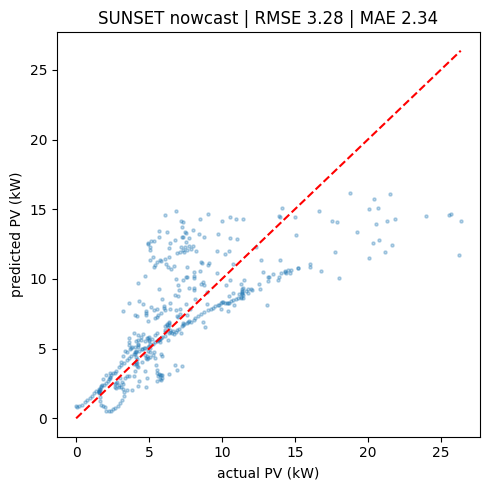

In [15]:
# predicted vs actual scatter over the whole test set
plt.figure(figsize=(5,5))
plt.scatter(y_test, prediction_ensemble, s=5, alpha=0.3)
lim = [0, max(y_test.max(), prediction_ensemble.max())]
plt.plot(lim, lim, 'r--')
plt.xlabel("actual PV (kW)"); plt.ylabel("predicted PV (kW)")
plt.title(f"SUNSET nowcast | RMSE {rmse:.2f} | MAE {mae:.2f}")
plt.tight_layout(); plt.show()

In [16]:
import os, h5py, numpy as np
from tensorflow import keras
import glob

BASE = "/content/drive/MyDrive/SKIPPD"
with h5py.File(os.path.join(BASE, "images_pv_processed.hdf5"), "r") as f:
    X_test = f["test/images_log"][...]
    y_test = f["test/pv_log"][...].astype("float32")

paths = sorted(glob.glob(os.path.join(BASE, "model_output", "SUNSET_nowcast_run",
                                      "repetition_*", "best_model_repitition_*.keras")))
print("models found:", len(paths))

preds = []
for p in paths:
    m = keras.models.load_model(p)
    preds.append(np.squeeze(m.predict(X_test, batch_size=200, verbose=0)))
ens = np.mean(preds, axis=0)

rmse = np.sqrt(np.mean((ens - y_test)**2))
mae  = np.mean(np.abs(ens - y_test))
print(f"Test RMSE: {rmse:.3f} kW")
print(f"Test MAE : {mae:.3f} kW")
print(f"PV range in test set: {y_test.min():.1f} .. {y_test.max():.1f} kW")

models found: 3
Test RMSE: 3.276 kW
Test MAE : 2.342 kW
PV range in test set: 0.0 .. 26.4 kW


Loading 3 models ...
  REGRESSION METRICS
  MAE   :   2.342 kW
  RMSE  :   3.276 kW
  MBE   :   0.122 kW   (bias, ~0 good)
  R^2   :   0.522
  Corr  :   0.729
  Skill :  30.89 %  (vs mean baseline)

  CLASSIFICATION METRICS  (bin edges kW: [ 0.   5.   7.7 26.4])
  Accuracy      : 0.686
  Precision (w) : 0.683
  Recall    (w) : 0.686
  F1-score  (w) : 0.669
  F1-score  (macro): 0.669

              precision  recall  f1_score  support
Low               0.820   0.739     0.778    142.0
Medium            0.574   0.380     0.458    142.0
High              0.654   0.937     0.770    143.0
macro avg         0.683   0.686     0.669    427.0
weighted avg      0.683   0.686     0.669    427.0

sklearn classification_report:
              precision    recall  f1-score   support

         Low       0.82      0.74      0.78       142
      Medium       0.57      0.38      0.46       142
        High       0.65      0.94      0.77       143

    accuracy                           0.69       427
   

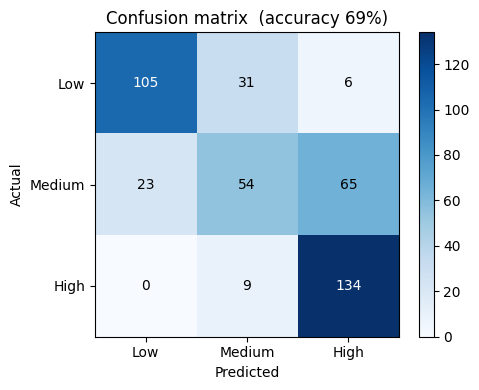

In [17]:
# ============================================================================
#  Nowcast — Complete Evaluation
#  Regression metrics (MAE/RMSE/R²…) + classification metrics
#  (accuracy, precision, recall, F1) via Low/Medium/High power binning.
# ============================================================================
import os, glob
import numpy as np, pandas as pd, h5py
import matplotlib.pyplot as plt
from tensorflow import keras
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, f1_score,
                             precision_recall_fscore_support)

BASE        = "/content/drive/MyDrive/SKIPPD"
NOWCAST_DIR = os.path.join(BASE, "model_output", "SUNSET_nowcast_run")
HDF5_PATH   = os.path.join(BASE, "images_pv_processed.hdf5")

# --- load test data + ensemble predictions ---
with h5py.File(HDF5_PATH, "r") as f:
    X_test = f["test/images_log"][...]
    y_test = f["test/pv_log"][...].astype("float32")

paths = sorted(glob.glob(os.path.join(NOWCAST_DIR, "repetition_*",
                                      "best_model_repitition_*.keras")))
assert paths, "No trained models found — train the nowcast notebook first."
print(f"Loading {len(paths)} models ...")
preds  = [np.squeeze(keras.models.load_model(p).predict(X_test, batch_size=200, verbose=0))
          for p in paths]
y_pred = np.clip(np.mean(preds, axis=0), 0, None)

# ========================= PART 1 — REGRESSION =========================
err  = y_pred - y_test
mae  = np.mean(np.abs(err))
rmse = np.sqrt(np.mean(err**2))
mbe  = np.mean(err)
r2   = 1 - np.sum(err**2)/np.sum((y_test - y_test.mean())**2)
corr = np.corrcoef(y_test, y_pred)[0, 1]
skill = 100*(1 - rmse/np.sqrt(np.mean((y_test - y_test.mean())**2)))

print("="*52)
print("  REGRESSION METRICS")
print("="*52)
print(f"  MAE   : {mae:7.3f} kW")
print(f"  RMSE  : {rmse:7.3f} kW")
print(f"  MBE   : {mbe:7.3f} kW   (bias, ~0 good)")
print(f"  R^2   : {r2:7.3f}")
print(f"  Corr  : {corr:7.3f}")
print(f"  Skill : {skill:6.2f} %  (vs mean baseline)")

# ================= PART 2 — CLASSIFICATION (binned) ====================
edges  = np.quantile(y_test, [0, 1/3, 2/3, 1.0])          # tertile thresholds
labels = ["Low", "Medium", "High"]
def to_class(v): return np.clip(np.digitize(v, edges[1:-1]), 0, 2)
t_cls, p_cls = to_class(y_test), to_class(y_pred)

acc = accuracy_score(t_cls, p_cls)
prec, rec, f1, support = precision_recall_fscore_support(
    t_cls, p_cls, labels=[0,1,2], zero_division=0)
macro    = precision_recall_fscore_support(t_cls, p_cls, average="macro",    zero_division=0)
weighted = precision_recall_fscore_support(t_cls, p_cls, average="weighted", zero_division=0)

print("\n" + "="*52)
print(f"  CLASSIFICATION METRICS  (bin edges kW: {np.round(edges,1)})")
print("="*52)
print(f"  Accuracy      : {acc:.3f}")
print(f"  Precision (w) : {weighted[0]:.3f}")
print(f"  Recall    (w) : {weighted[1]:.3f}")
print(f"  F1-score  (w) : {weighted[2]:.3f}")
print(f"  F1-score  (macro): {macro[2]:.3f}\n")

table = pd.DataFrame({"precision":prec, "recall":rec, "f1_score":f1, "support":support},
                     index=labels).round(3)
table.loc["macro avg"]    = [macro[0],    macro[1],    macro[2],    support.sum()]
table.loc["weighted avg"] = [weighted[0], weighted[1], weighted[2], support.sum()]
print(table.round(3).to_string())

print("\nsklearn classification_report:")
print(classification_report(t_cls, p_cls, target_names=labels, zero_division=0))

# ===================== PART 3 — CONFUSION MATRIX =======================
cm = confusion_matrix(t_cls, p_cls, labels=[0,1,2])
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(3)); ax.set_xticklabels(labels)
ax.set_yticks(range(3)); ax.set_yticklabels(labels)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title(f"Confusion matrix  (accuracy {acc:.0%})")
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black")
plt.colorbar(im); plt.tight_layout(); plt.show()